# **공모전 제출 파일**

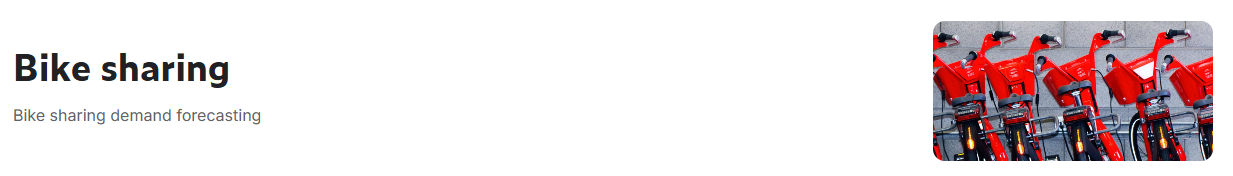

* https://www.kaggle.com/competitions/bike-sharing-demand
* ref) https://www.kaggle.com/code/shotasekido/s-sekido-bike-sharing-demand-report

In [1]:
from sklearn import set_config
set_config(display="text")          #인코딩 텍스트로 바꿔달라는

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.model_selection import train_test_split     #문제/답 분리
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor    #회귀모델 (트리모델)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler    #정규화(스케일링)

from sklearn.metrics import root_mean_squared_log_error  #평가 매트릭스(rmsle)


#차트 관련 속성 (한글처리, 그리드)  폰트 설정 가능
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# **[1] Data Load**

In [3]:
train = pd.read_csv("../datas/bike/train.csv", parse_dates=['datetime'])  #parse_dates=['datetime'] : 글자로 되어있는 datetime을 애초에 날짜 형식으로 캐스팅(변환)
test = pd.read_csv("../datas/bike/test.csv", parse_dates=['datetime'])
sub = pd.read_csv("../datas/bike/sampleSubmission.csv")

In [4]:
train.shape, test.shape, sub.shape

((10886, 12), (6493, 9), (6493, 2))

In [5]:
train.head(2)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40


In [6]:
test.head(2)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000


In [7]:
sub.head(2)

,datetime,count
0,2011-01-20 00:00:00,0
1,2011-01-20 01:00:00,0


In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [9]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    6493 non-null   datetime64[us]
 1   season      6493 non-null   int64         
 2   holiday     6493 non-null   int64         
 3   workingday  6493 non-null   int64         
 4   weather     6493 non-null   int64         
 5   temp        6493 non-null   float64       
 6   atemp       6493 non-null   float64       
 7   humidity    6493 non-null   int64         
 8   windspeed   6493 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(5)
memory usage: 456.7 KB


* <font color='red'> 결측 없음
* <font color='red'> 글자 있음 > datetime=str : 연월일시 숫자로 분리하면 datetime은 버려도 됨
* 문제지/답안지 나눠져있기 때문에 별도로 지정 안 해도 됨

## 연월일시 분리

In [10]:
train['yy']   = train['datetime'].dt.year
train['mm']   = train['datetime'].dt.month
train['dd']   = train['datetime'].dt.day
train['hh']   = train['datetime'].dt.hour
train['week'] = train['datetime'].dt.weekday             #월요일~일요일 : 순서대로 0~6
#train['date'] = train['datetime'].dt.date                #전체날짜
train['woy']  = train['datetime'].dt.isocalendar().week   #몇주차


test['yy']   = test['datetime'].dt.year
test['mm']   = test['datetime'].dt.month
test['dd']   = test['datetime'].dt.day
test['hh']   = test['datetime'].dt.hour
test['week'] = test['datetime'].dt.weekday
#test['date'] = test['datetime'].dt.date                
test['woy']  = test['datetime'].dt.isocalendar().week  

## 달력 공휴일 추가

In [11]:
dates = [
    (pd.Timestamp(2011, 4, 15), 1, 0),  # Tax day
    (pd.Timestamp(2012, 4, 16), 1, 0),  # Tax day
    (pd.Timestamp(2011, 11, 25), 0, 1),  # Thanksgiving Friday
    (pd.Timestamp(2012, 11, 23), 0, 1),  # Thanksgiving Friday
    (pd.Timestamp(2011, 12, 24), 0, 1),  # Christmas
    (pd.Timestamp(2012, 12, 24), 0, 1),  # Christmas
    (pd.Timestamp(2011, 12, 26), 0, 1),  # Christmas
    (pd.Timestamp(2012, 12, 26), 0, 1),  # Christmas
    (pd.Timestamp(2011, 12, 31), 0, 1),  #New Year’s Eve
    (pd.Timestamp(2012, 12, 31), 0, 1),  #New Year’s Eve
    (pd.Timestamp(2012, 5, 21), 0, 1),  # Storms
    (pd.Timestamp(2012, 6, 1), 0, 1),  # Tornado
    (pd.Timestamp(2012, 10, 30), 0, 1),  # Sandy
]

In [12]:
for date, workingday_value, holiday_value in dates:
    train.loc[train['datetime'].dt.date == date.date(),'workingday'] = workingday_value
    train.loc[train['datetime'].dt.date == date.date(),'holiday'] = holiday_value

for date, workingday_value, holiday_value in dates:
    test.loc[test['datetime'].dt.date == date.date(),'workingday'] = workingday_value
    test.loc[test['datetime'].dt.date == date.date(),'holiday'] = holiday_value

In [13]:
train = train.set_index("datetime")
test  = test.set_index("datetime")

# **[2] EDA(Exploratory Data Analysis)**

## hist() : 데이터 분포도 확인(왜도, 첨도, 정규분포)

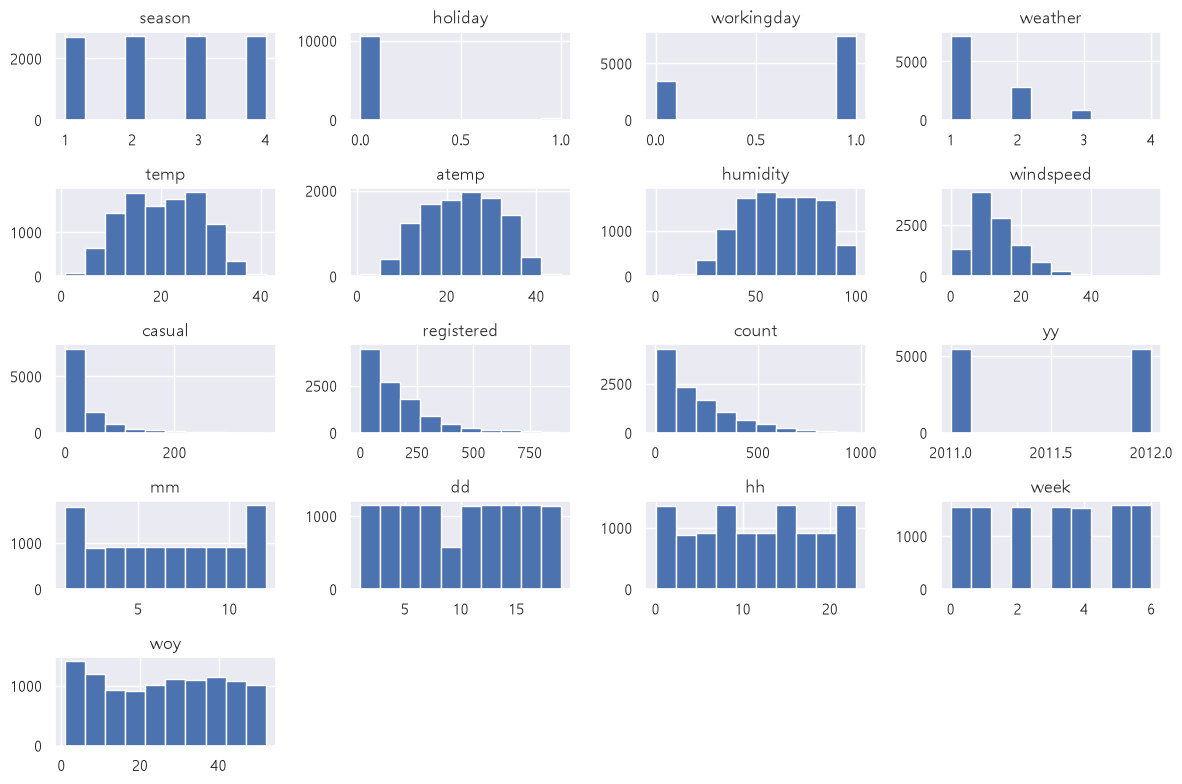

In [14]:
train.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

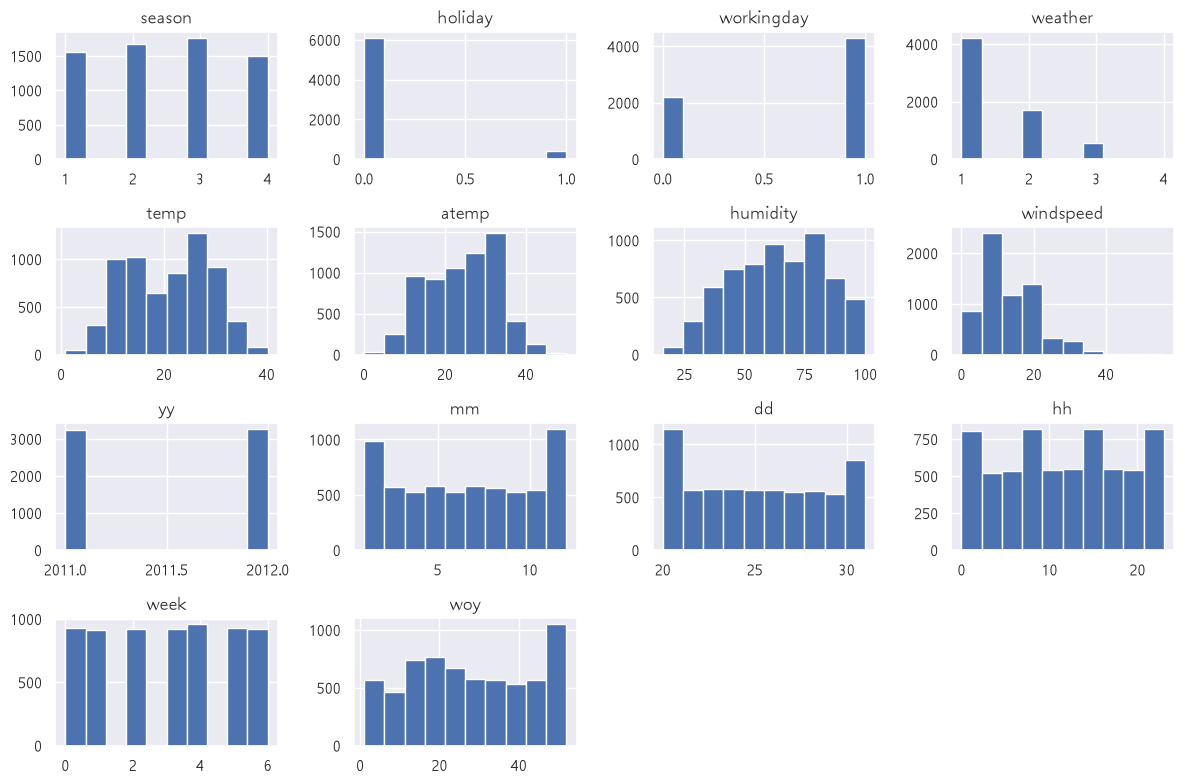

In [15]:
test.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

<font color=blue> **▼ 분석**
* train & test 비교했을 때
* casual과 registered가 왜 필요한지 확인 필요
* ['dd'] 컬럼 확인
  * train['dd'] = 1~20일
  * test['dd'] = 21~말일
   <font color=red>--> dd컬럼 비교가 불가능하기 때문에 삭제

## 상관분석

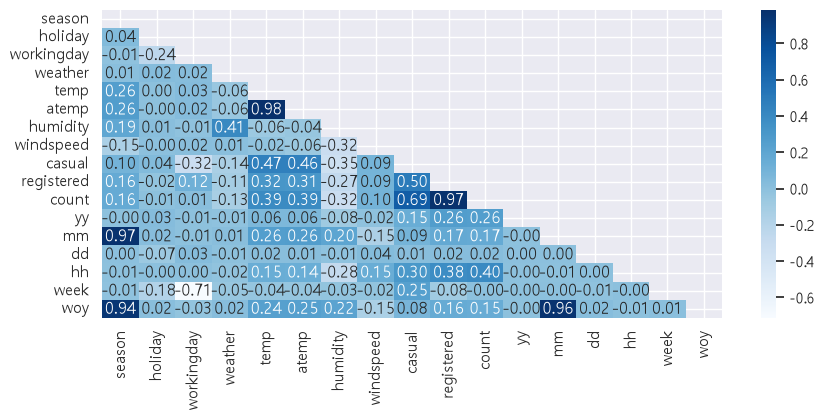

In [16]:
plt.figure(figsize=(10, 4))

# 반쪽으로 보기
mask = np.triu(np.ones_like(train.corr(), dtype=bool))
sns.heatmap(train.corr(), annot=True, fmt=".2f", cmap="Blues", mask=mask)    #.2f = 소수점 2자리까지~ (d=숫자로)
plt.show()
# test에는 타겟피쳐가 없기 때문에 train만 봐도 됨

* atemp & temp : 0.98  --> 바이크 대여 수에 영향 큼
* count & registered : 0.97 (casual + registered = count 당연한 결과)
* workingday & week : -0.7
* mm & season : 0.97
* <font color="blue"> mm, week : 파생피쳐(연월일시 분리) 추가 생성으로 다중공선이 됨 : 필요시 파생피쳐는 삭제

<pre>

- 날짜 : 'yy', 'mm', 'hh', 'season'
- 날씨 : 'weather', 'temp', 'atemp', 'humidity', 'windspeed'
- 타겟 : 'casual', 'registered', 'count'
- 휴일 : 'holiday', 'workingday', 'week'

<font color="green"> <b> --> 날짜/날씨/휴일 분석 필요

### **날짜**
* 'yy', 'mm', 'hh', 'season'

#### 연/월/시간/계절별 대여수

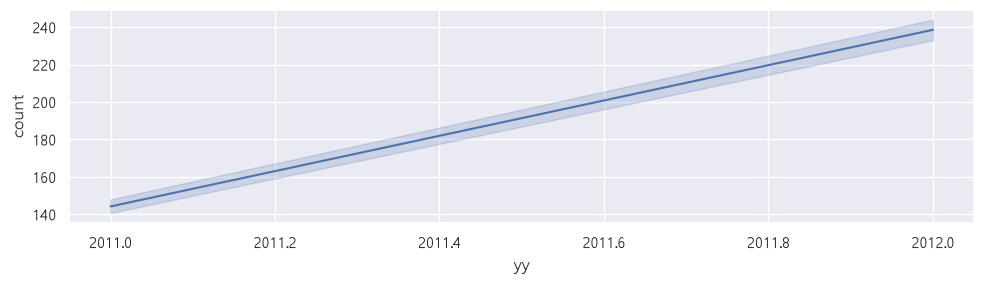

In [17]:
plt.figure(figsize=(10,3))
sns.lineplot(x="yy", y="count", data=train)
plt.tight_layout()
plt.show()

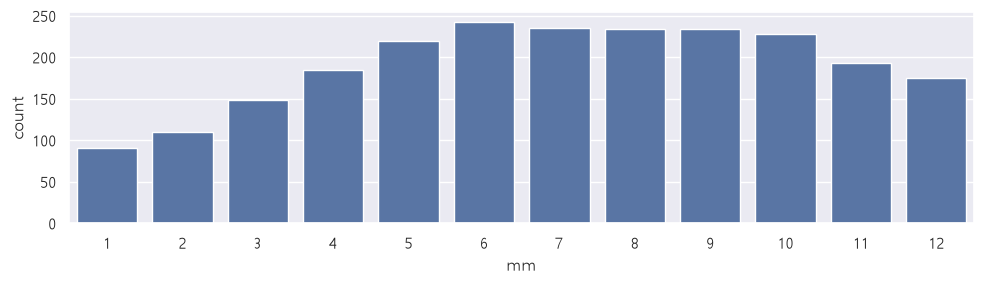

In [18]:
plt.figure(figsize=(10,3))
sns.barplot(x="mm", y="count", data=train, errorbar=None)
plt.tight_layout()
plt.show()

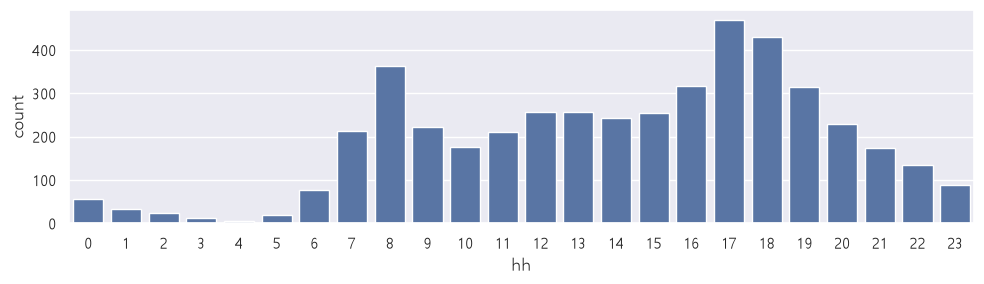

In [19]:
plt.figure(figsize=(10,3))
sns.barplot(x="hh", y="count", data=train, errorbar=None)
plt.tight_layout()
plt.show()

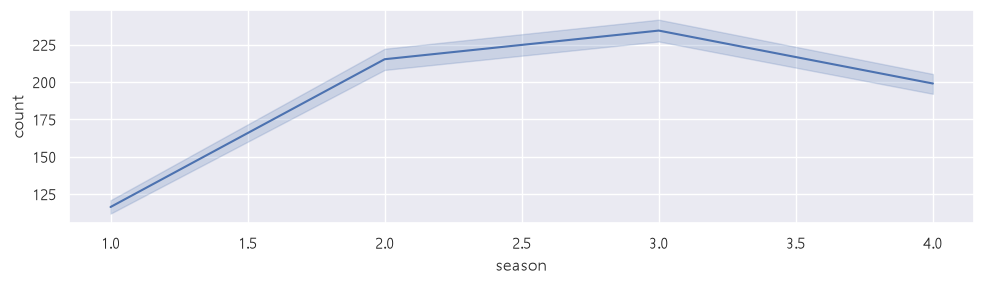

In [20]:
plt.figure(figsize=(10,3))
sns.lineplot(x="season", y="count", data=train)
plt.tight_layout()
plt.show()

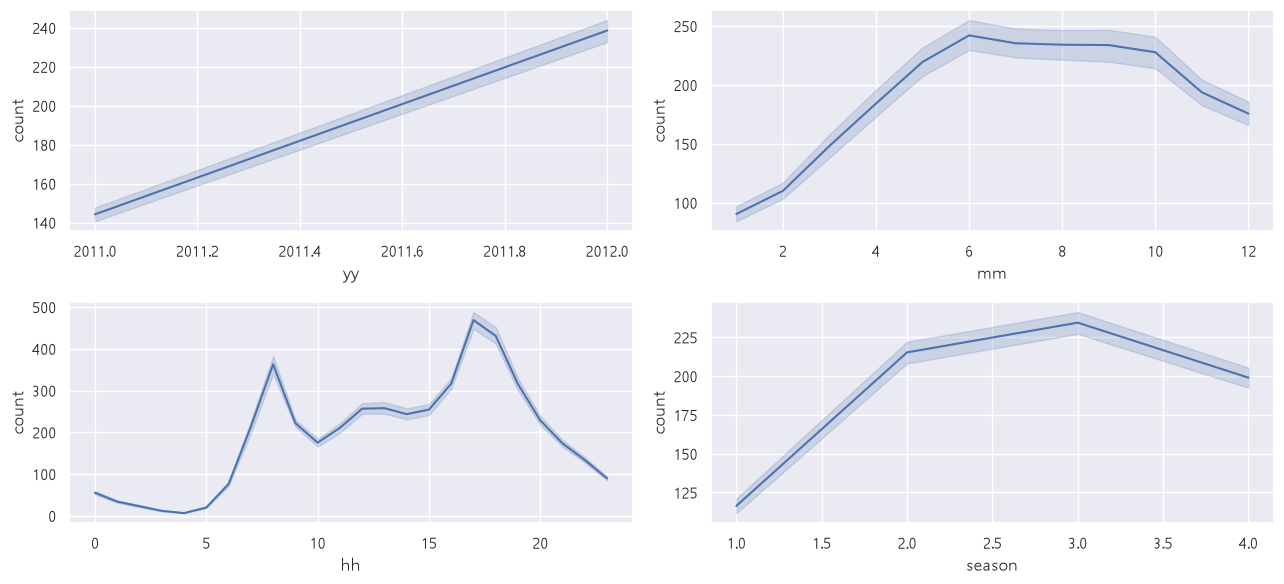

In [21]:
plt.figure(figsize=(13,6))


plt.subplot(2, 2, 1)
sns.lineplot(x="yy", y="count", data=train)

plt.subplot(2, 2, 2) 
sns.lineplot(x="mm", y="count", data=train)

plt.subplot(2, 2, 3) 
sns.lineplot(x="hh", y="count", data=train)

plt.subplot(2, 2, 4) 
sns.lineplot(x="season", y="count", data=train)


plt.tight_layout()
plt.show()

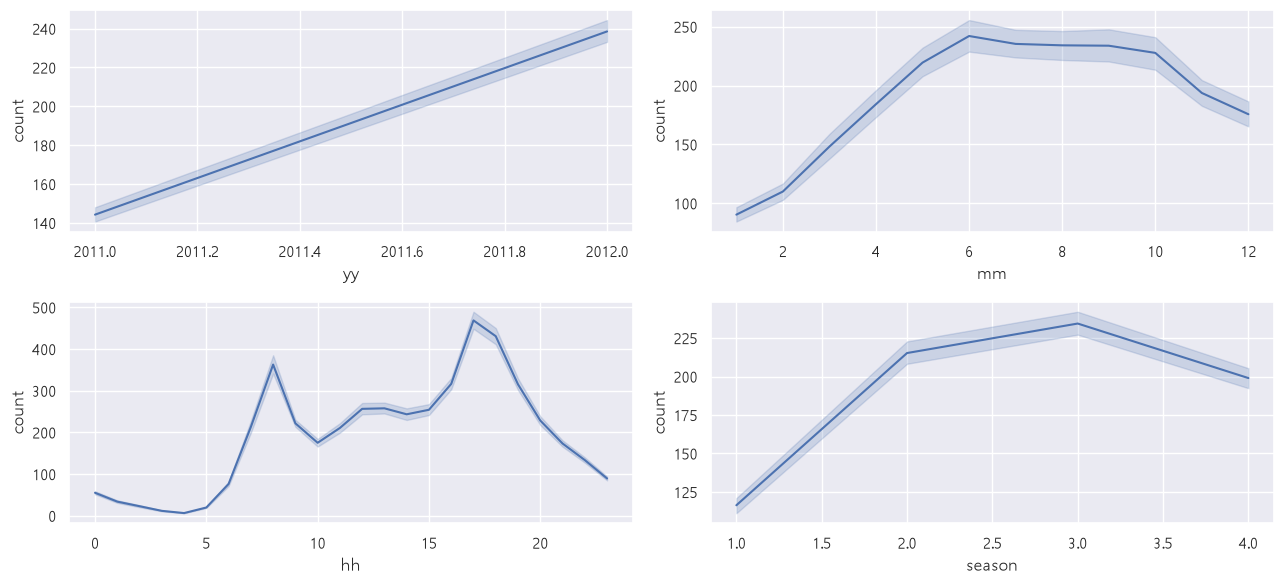

In [22]:
#반복문 사용!

fig, axes = plt.subplots(2,2, figsize=(13,6))
col_list=['yy', 'mm', 'hh', 'season']

for i, col in enumerate(col_list) :
    # 인덱스로 대입하니까 변수를 i로
    # 2*2에 0, 1이 루프돌며 차례대로 나와야 하니까 몫과 나머지로 인덱스 처리
    줄 = i//2   #몫 
    칸 = i%2    #나머지
    sns.lineplot(x=col, y="count", data=train, ax=axes[줄][칸])

plt.tight_layout()
plt.show()

### **날씨**
* 'weather', 'temp', 'atemp', 'humidity', 'windspeed'

#### 날씨/온도/체감온도/습도/풍속 별 대여수

<font color=red> <b> 현장대여수(casual) : 온도만 봐도 예측 가능

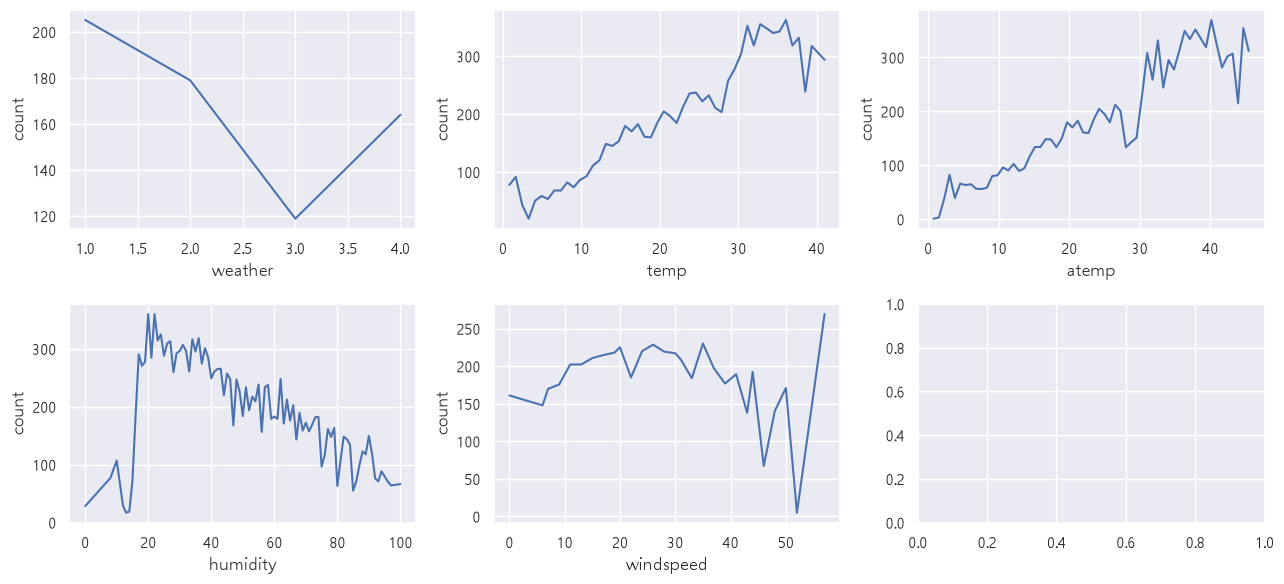

In [23]:
fig, axes = plt.subplots(2,3, figsize=(13,6))
col_list2=['weather', 'temp', 'atemp', 'humidity', 'windspeed']

for i, col2 in enumerate(col_list2) :
    # 인덱스로 대입하니까 변수를 i로
    # 2*3에 0, 1이 루프돌며 차례대로 나와야 하니까 몫과 나머지로 인덱스 처리
    줄 = i//3   #몫 
    칸 = i%3    #나머지
    sns.lineplot(x=col2, y="count", data=train, errorbar=None, ax=axes[줄][칸])

plt.tight_layout()
plt.show()

#### **temp**

* 라인 : 평균온도
* 바 : 대여수

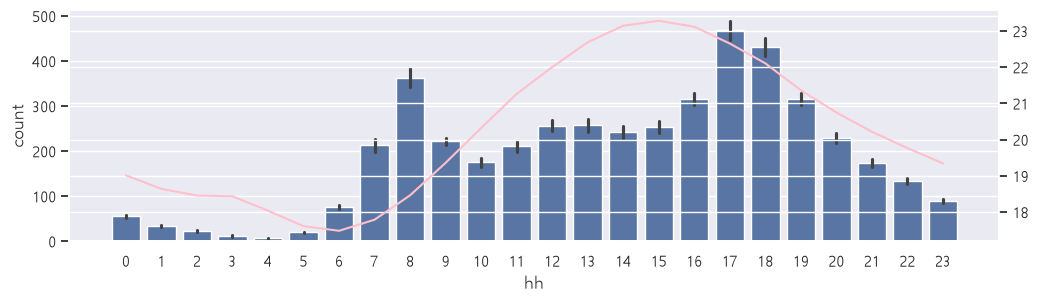

In [24]:
fig, axes = plt.subplots(figsize=(12,3))
sns.barplot(data=train, x="hh", y="count", ax=axes)
axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['temp']].mean(), color='pink' )
plt.show()

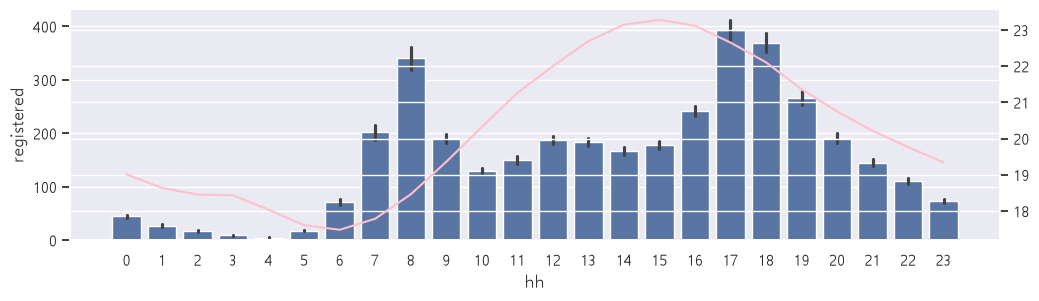

In [25]:
fig, axes = plt.subplots(figsize=(12,3))
sns.barplot(data=train, x="hh", y="registered", ax=axes)
axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['temp']].mean(), color='pink' )
plt.show()

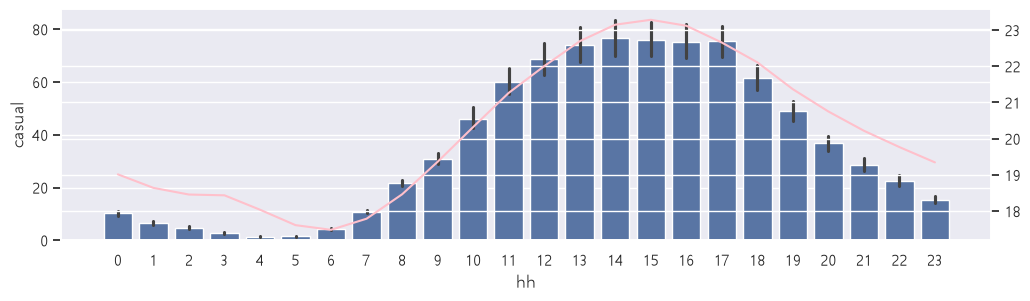

In [26]:
fig, axes = plt.subplots(figsize=(12,3))
sns.barplot(data=train, x="hh", y="casual", ax=axes)
axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['temp']].mean(), color='pink' )
plt.show()

#### **humidity**

* 라인 : 평균습도
* 바 : 대여수

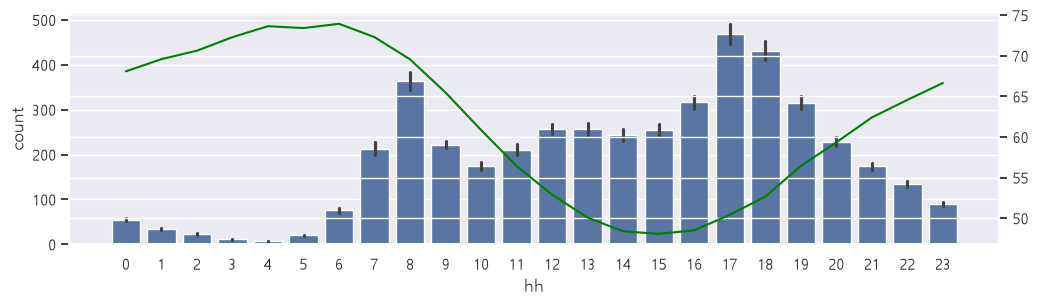

In [27]:
fig, axes = plt.subplots(figsize=(12,3))
sns.barplot(data=train, x="hh", y="count", ax=axes)
axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['humidity']].mean(), color='green' )
plt.show()

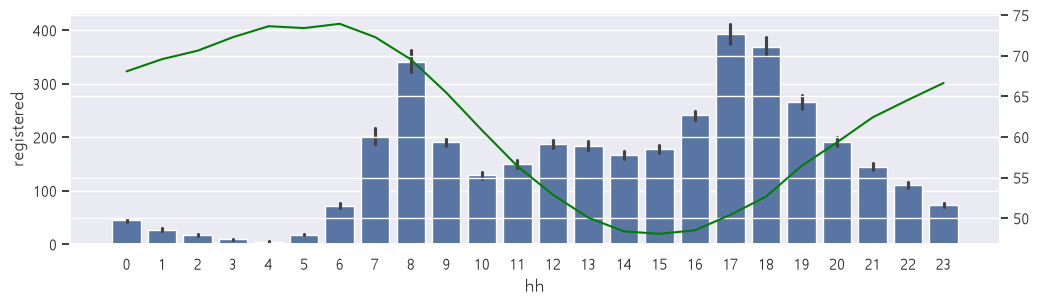

In [28]:
fig, axes = plt.subplots(figsize=(12,3))
sns.barplot(data=train, x="hh", y="registered", ax=axes)
axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['humidity']].mean(), color='green' )
plt.show()

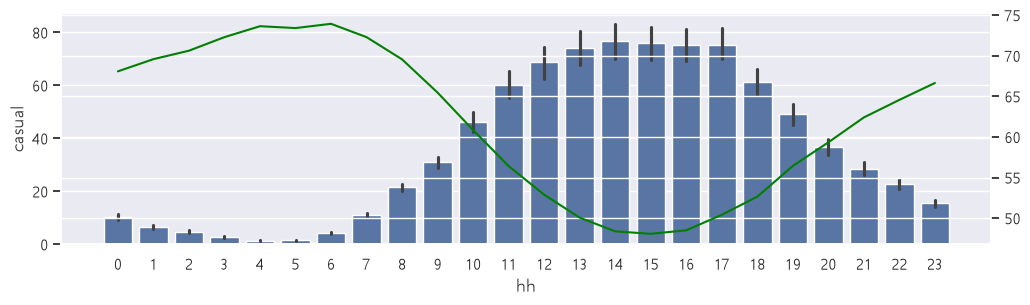

In [29]:
fig, axes = plt.subplots(figsize=(12,3))
sns.barplot(data=train, x="hh", y="casual", ax=axes)
axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['humidity']].mean(), color='green' )
plt.show()

#### **windspeed**

* 라인 : 풍속 평균
* 바 : 대여수

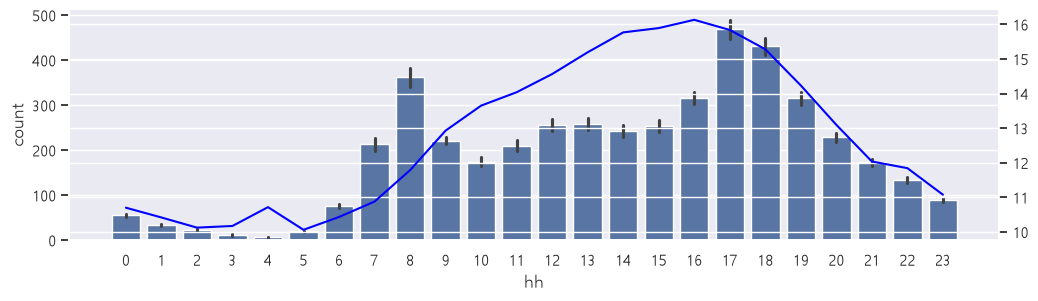

In [30]:
fig, axes = plt.subplots(figsize=(12,3))
sns.barplot(data=train, x="hh", y="count", ax=axes)
axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['windspeed']].mean(), color='blue' )
plt.show()

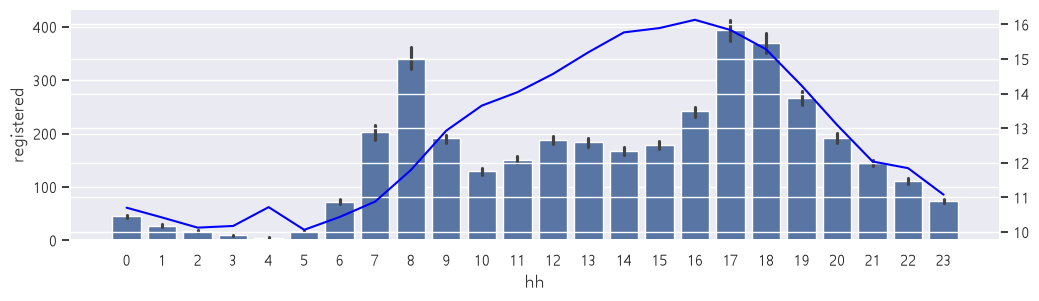

In [31]:
fig, axes = plt.subplots(figsize=(12,3))
sns.barplot(data=train, x="hh", y="registered", ax=axes)
axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['windspeed']].mean(), color='blue' )
plt.show()

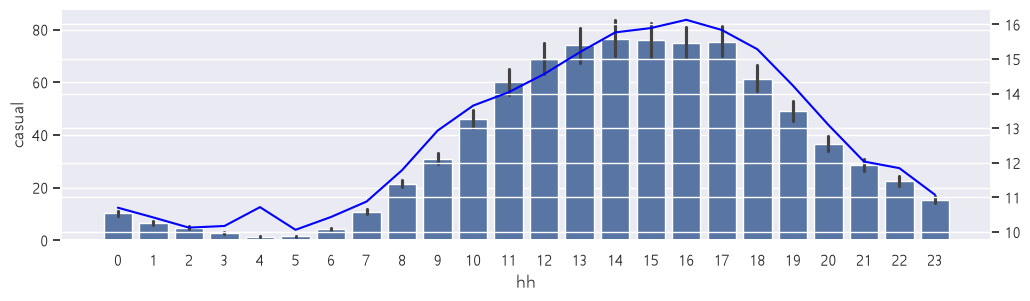

In [32]:
fig, axes = plt.subplots(figsize=(12,3))
sns.barplot(data=train, x="hh", y="casual", ax=axes)
axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['windspeed']].mean(), color='blue' )
plt.show()

#### **weather**

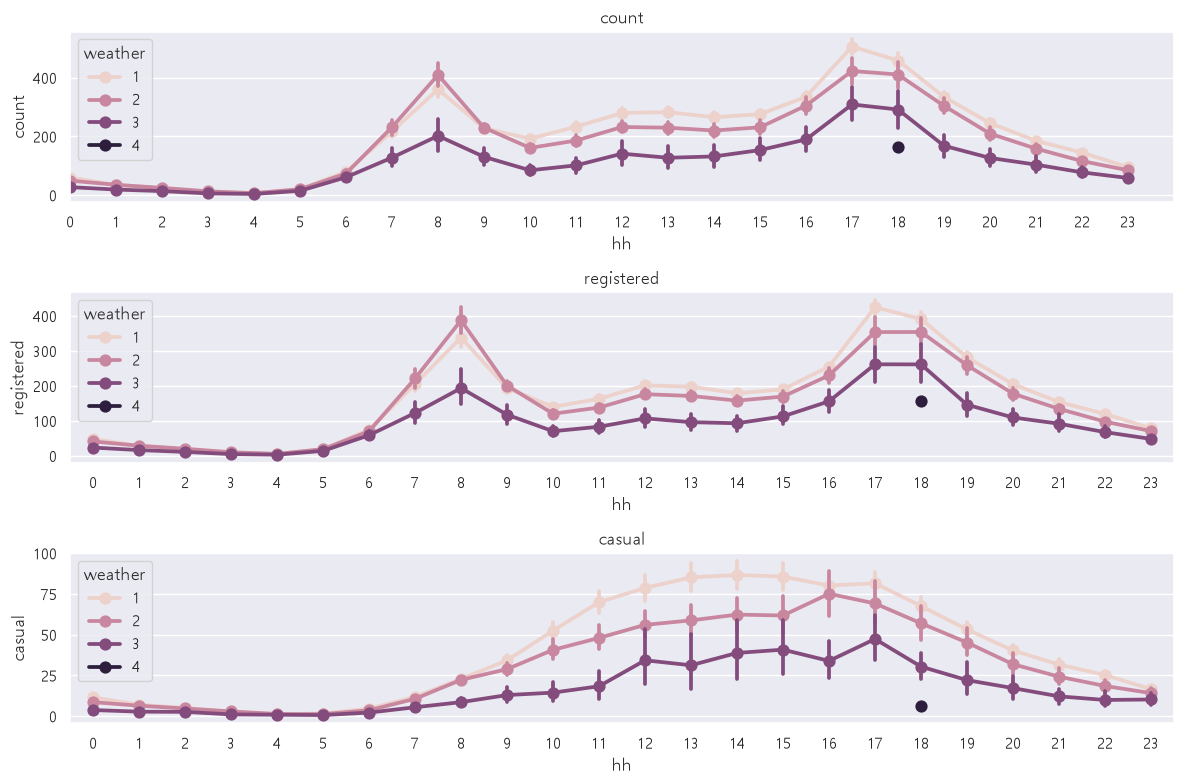

In [33]:
fig,ax = plt.subplots(nrows=3,ncols=1, figsize=(12,8))

sns.pointplot(data=train, x='hh', y='count', hue='weather', ax=ax[0])
ax[0].set(xlim=(0, 24))
ax[0].set(title="count")

sns.pointplot(data=train, x='hh', y='registered', hue='weather', ax=ax[1])
ax[1].set(title="registered")

sns.pointplot(data=train, x='hh', y='casual', hue='weather', ax=ax[2])
ax[2].set(title="casual")

plt.tight_layout()
plt.show()

### 타겟
* 'count'(총합), 'registered'(예약), 'casual'(현장)

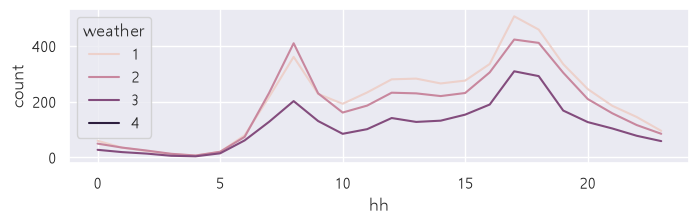

In [34]:
#계절(weather 그룹화_hue)별 시간대별 바이크대여

plt.figure(figsize=(8,2))
sns.lineplot(x='hh', y="count", hue="weather", data=train, errorbar=None)
plt.show()

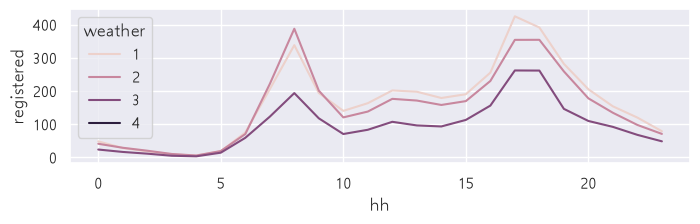

In [35]:
#계절(weather 그룹화_hue)별 시간대별 예약대여수

plt.figure(figsize=(8,2))
sns.lineplot(x='hh', y="registered", hue="weather", data=train, errorbar=None)
plt.show()

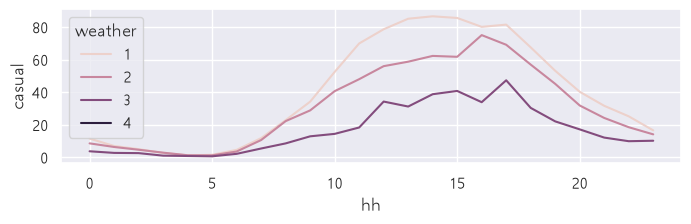

In [36]:
#계절(weather 그룹화_hue)별 시간대별 현장대여수

plt.figure(figsize=(8,2))
sns.lineplot(x='hh', y="casual", hue="weather", data=train, errorbar=None)
plt.show()

#### weather 4가 안 찍히는 이유!
  * 만몇개 중에 한줄밖에 없어서... 현장대여... 한겨울에... 월요일에... 습도가 86...

In [37]:
train[ train['weather']==4 ]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,yy,mm,dd,hh,week,woy
datetime,,,,,,,,,,,,,,,,,
2012-01-09 18:00:00,1,0,1,4,8.2,11.365,86,6.0032,6,158,164,2012,1,9,18,0,2


* 이새끼는 풍속이 22인데...
* 새벽 한시에는 왜 빌린걸까

In [38]:
test[ test['weather']==4 ]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,yy,mm,dd,hh,week,woy
datetime,,,,,,,,,,,,,,
2011-01-26 16:00:00,1,0,1,4,9.02,9.85,93,22.0028,2011,1,26,16,2,4
2012-01-21 01:00:00,1,0,0,4,5.74,6.82,86,12.9980,2012,1,21,1,5,3


### **평일/휴일**
* 'holiday', 'workingday', 'week'

#### 공휴일/워킹데이(평일/주말) 대여수

In [39]:
train[['holiday','workingday']].value_counts()

#행 순서대로
#평일(까만날) - 7412
#주말(쉬는날) - 3163
#공휴일       - 311
#개복잡하니까 이럴 때 파생피쳐 만들어야 함

holiday  workingday
0        1             7436
         0             3163
1        0              287
Name: count, dtype: int64

#### **데이터 수정**

In [40]:
train['day_type'] = 0

#holiday==0  workingday==1  : 그냥 까만 평일
train.loc [ (train['holiday']==0) & (train['workingday']==1), 'day_type' ] = 0

#holiday==0  workingday==0  : 공휴일도 평일도 아닌 주말
train.loc [ (train['holiday']==0) & (train['workingday']==0), 'day_type' ] = 1

#holiday==1  workingday==0  : 공휴일
train.loc [ (train['holiday']==1) & (train['workingday']==0), 'day_type' ] = 2

train['day_type'].value_counts()

day_type
0    7436
1    3163
2     287
Name: count, dtype: int64

In [41]:
test['day_type'] = 0

#holiday==0  workingday==1  : 그냥 까만 평일
test.loc [ (test['holiday']==0) & (test['workingday']==1), 'day_type' ] = 0

#holiday==0  workingday==0  : 공휴일도 평일도 아닌 주말
test.loc [ (test['holiday']==0) & (test['workingday']==0), 'day_type' ] = 1

#holiday==1  workingday==0  : 공휴일
test.loc [ (test['holiday']==1) & (test['workingday']==0), 'day_type' ] = 2

test['day_type'].value_counts()

day_type
0    4299
1    1803
2     391
Name: count, dtype: int64

#### **day_type별 count 평균**

In [42]:
train[ train['day_type']==0 ].groupby('hh')['count'].mean()

hh
0      36.556270
1      15.980645
2       8.460784
3       4.900000
4       5.355705
5      24.469453
6     102.372990
7     290.186495
8     479.054662
9     242.083601
10    133.623794
11    157.003215
12    199.224359
13    196.935897
14    180.419872
15    198.564103
16    292.743590
17    530.128205
18    496.554487
19    350.362179
20    250.019231
21    185.185897
22    138.769231
23     89.070513
Name: count, dtype: float64

#### **day_type별 현황 시각화**

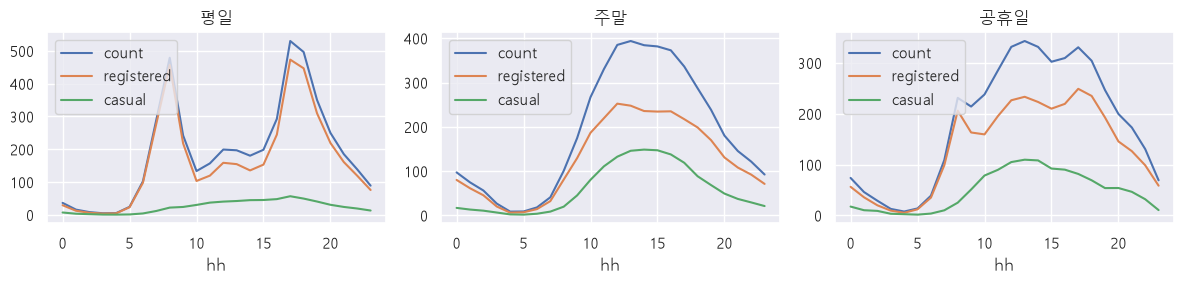

In [43]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 3)) 

g0 = train[ train['day_type']==0 ].groupby('hh')[['count', 'registered', 'casual']].mean() 
g0.plot(ax=ax1, title='평일')

g1 = train[ train['day_type']==1 ].groupby('hh')[['count', 'registered', 'casual']].mean() 
g1.plot(ax=ax2, title='주말')

g2 = train[ train['day_type']==2 ].groupby('hh')[['count', 'registered', 'casual']].mean()
g2.plot(ax=ax3, title='공휴일')

plt.tight_layout()
plt.show()

### **요일(파생피쳐)별 대여수**
* 'week'

#### **요일/휴일 별 대여(예약/현장/총합) 현황 시각화**

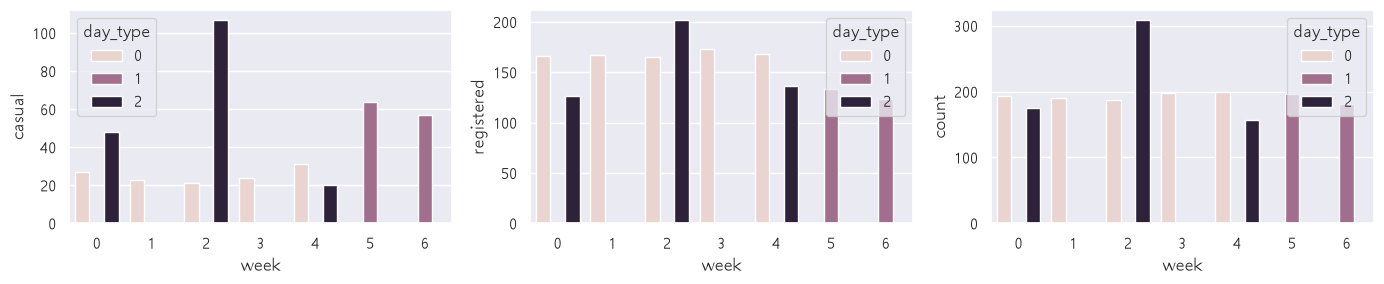

In [44]:
fig, axes = plt.subplots(1,3, figsize=(14,3))
col_list3=['casual', 'registered', 'count']

for i, col3 in enumerate(col_list3) :
    줄 = i//3   #몫 
    칸 = i%3    #나머지
    sns.barplot(x="week", y=col3, data=train, hue="day_type", errorbar=None, ax=axes[i])

plt.tight_layout()
plt.show()

<font color=blue> **▼ 분석**
* daytype 2 : 평일 중에 week 2 수요일이 너무 큼
     * 이유 확인 필요 : 매년 7월, 미국 독립기념일 불꽃놀이 대규모 축제
     * 아웃라이어 아님
* 2012년 10월 말 : 허리케인 샌디
     * 아웃라이어

### **월(파생피쳐)별 대여수**
* 'mm'

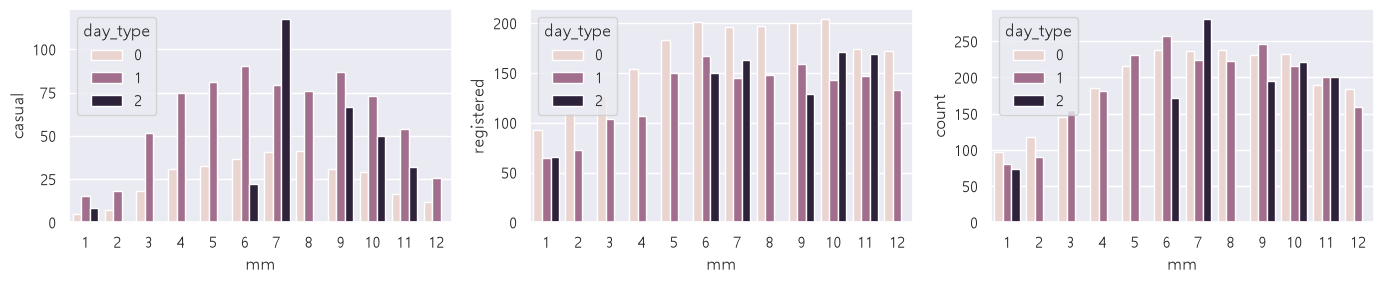

In [45]:
fig, axes = plt.subplots(1,3, figsize=(14,3))
col_list3=['casual', 'registered', 'count']

for i, col3 in enumerate(col_list3) :
    줄 = i//3   #몫 
    칸 = i%3    #나머지
    sns.barplot(x="mm", y=col3, data=train, hue="day_type", errorbar=None, ax=axes[i])

plt.tight_layout()
plt.show()

## 이상치(outlier)

### 박스플롯 시각화
* 박스플롯은 이상치 확인뿐만 아니라 중앙값으로 영향정도도 확인 가능

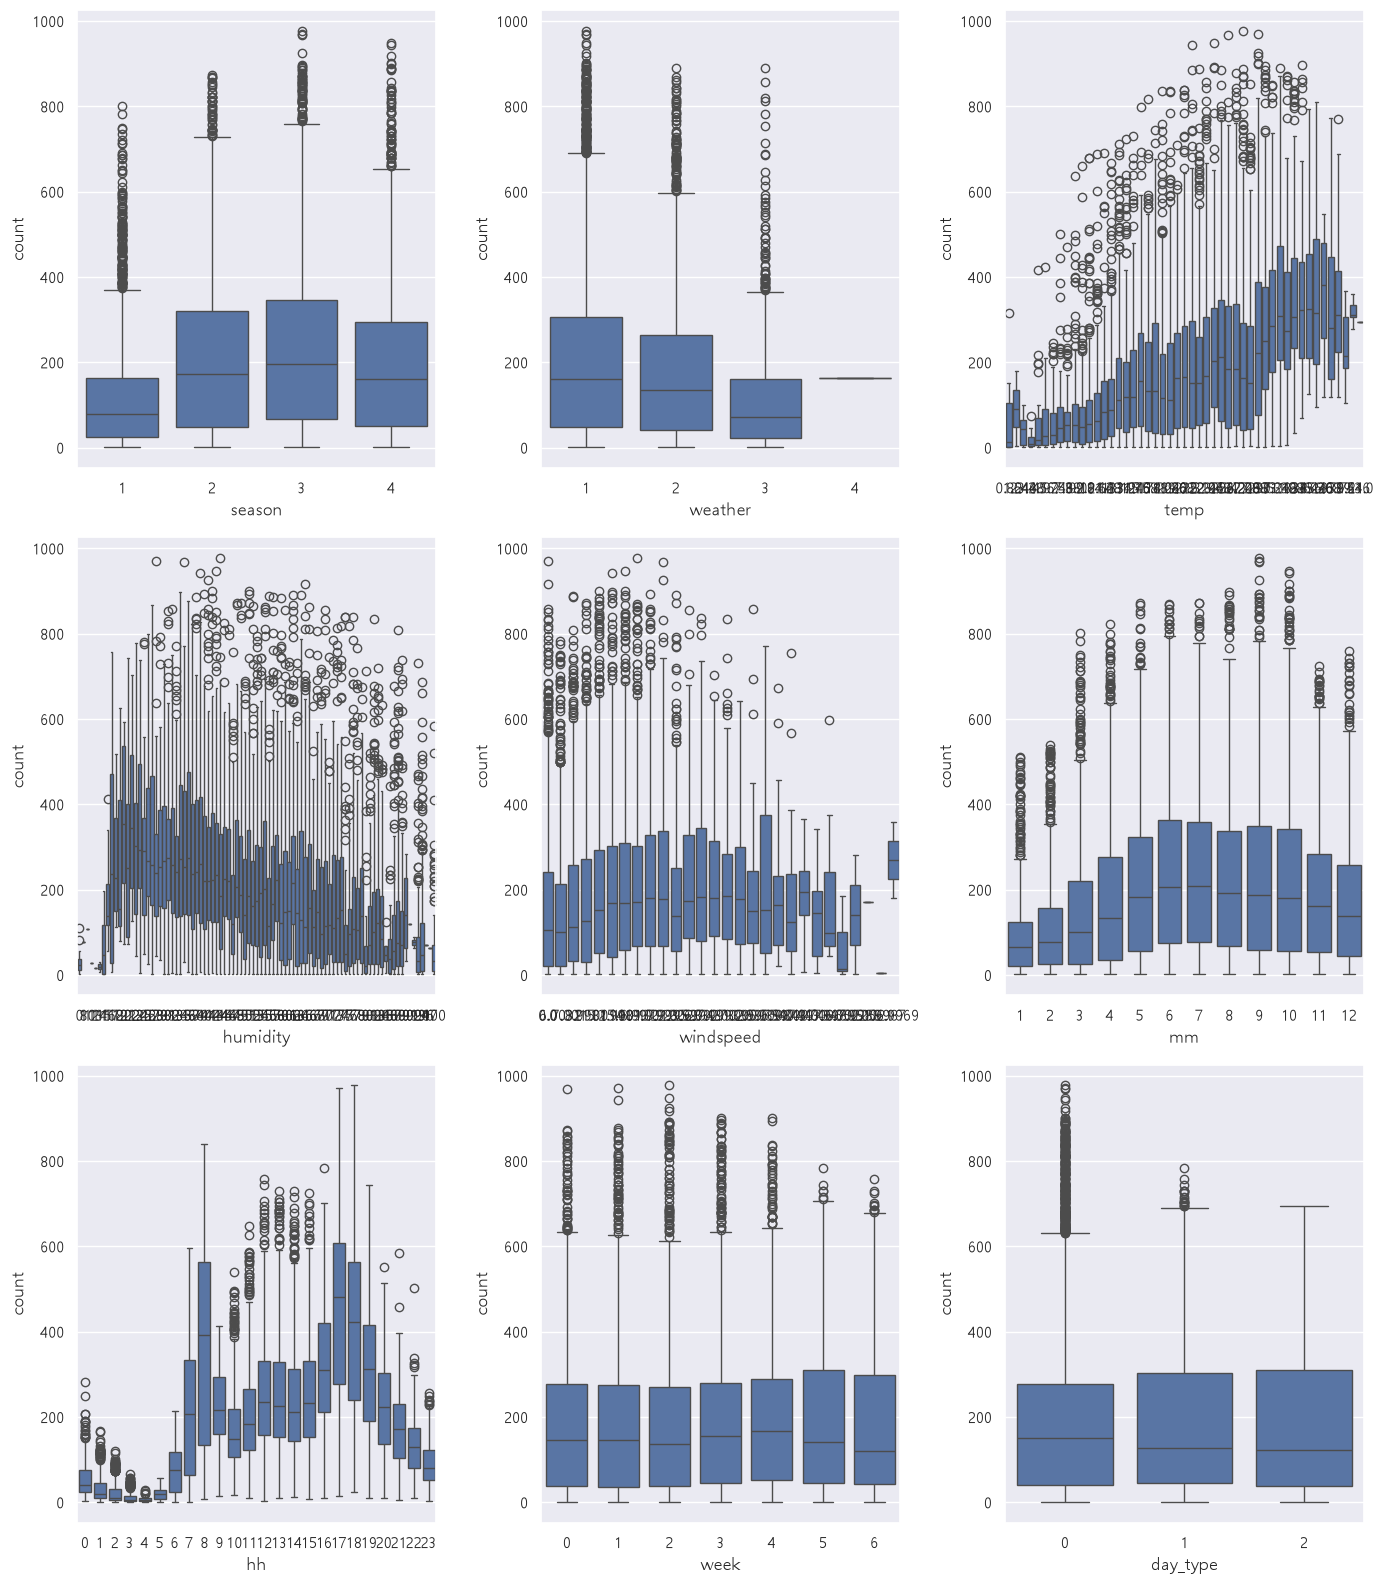

In [46]:
fig, axes = plt.subplots(3,3, figsize=(14,16))
col_list = ['season', 'weather', 'temp', 'humidity', 'windspeed', 'mm', 'hh', 'week', 'day_type']

for i, col in enumerate(col_list) :
    줄 = i//3 
    칸 = i%3 
    sns.boxplot(x=col, y="count", data=train, ax=axes[줄][칸])

plt.tight_layout()
plt.show()

In [47]:
train['windspeed'].value_counts()
#풍속이 0??? >> 이상치

windspeed
0.0000     1313
8.9981     1120
11.0014    1057
12.9980    1042
7.0015     1034
15.0013     961
6.0032      872
16.9979     824
19.0012     676
19.9995     492
22.0028     372
23.9994     274
26.0027     235
27.9993     187
30.0026     111
31.0009      89
32.9975      80
35.0008      58
39.0007      27
36.9974      22
43.0006      12
40.9973      11
43.9989       8
46.0022       3
56.9969       2
47.9988       2
51.9987       1
50.0021       1
Name: count, dtype: int64

### 풍속 0 : 이상치
* 0.0000 : 1313건

In [48]:
train[train['windspeed']==0].head(3)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,yy,mm,dd,hh,week,woy,day_type
datetime,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,5,52,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,5,52,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,5,52,1


### 습도 < 2 : 이상치

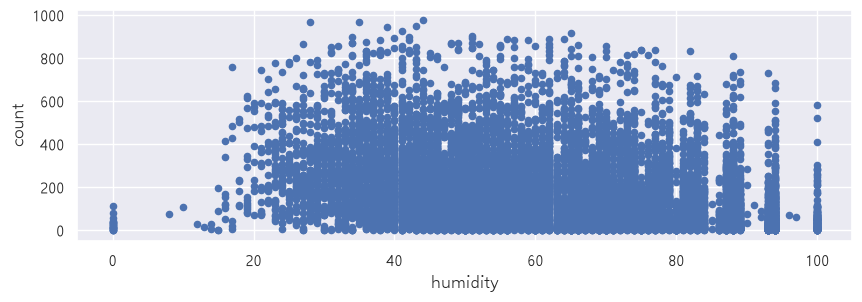

In [49]:
train.plot.scatter(x='humidity', y='count', figsize=(10,3))
plt.show()

# **[3] 타겟 로그변환**
* 범주형(0,1,2) 제외
* 연속형만 가공
* 로그변환은 일반적으로 target을 변환
* 로그 변환한 것은 추후 원상복귀 필요 : log1p() --> expm1()

In [50]:
train['count']      = np.log1p(train['count'])
train['registered'] = np.log1p(train['registered'])
train['casual']     = np.log1p(train['casual'])
#log1p : 로그로 변환 시 음수로 되기 때문에 +1

# **[4] 공통함수**

### RMSLE
* <font color=red> <b> 정확도가 중요한 데이터에 사용 </font> </b>
  * ex) 실제 10 > 예측 20 : 2배   /  실제 1000 > 예측 1010 : 1.01배  ==> MSLE에서는 첫번째 오차를 훨씬 심각하게 봄 <br>
* MSE: 실제값과 예측값의 차이를 그대로 제곱해 평가하는 지표
* RMSLE: 실제값과 예측값에 로그를 적용해 비율 차이를 중심으로 평가하는 지표

$RMSLE=\sqrt{\frac{1}{n} \sum_{i=1}^n (\log(p_i + 1) - \log(a_i+1))^2 }$ <br>
* mse에 log를 적용하는 이유 : 너무 큰 데이터의 영향을 줄이고, 큰 값과 작은 값의 차이를 상대적으로 다루기 위해서 <br>
* +1을 하는 이유 : 값이 0일 때도 log를 계산할 수 있도록

``` python
sklearn.metrics.root_mean_squared_log_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')

## **myscore222() 함수**

▼ train 데이터 통으로 넣을 경우
* 모델 지정 안 하면 기본 랜덤포레스트, 그게 아니면 모델 이름도 같이 출력
* 타겟 지정 안 하면 기본 count, 지정(입력)하면 그걸로

In [51]:
def myscore222(df,  model_r=None, model_c=None, input_cols=[]) :    
    #X_train7, X_test3,    y_train7, y_test3 = train_test_split( X, y, test_size=0.3, shuffle=False)
    #---7 : 3 분리
    train = df[df['dd'] <= 15]  #-----7
    val   = df[df['dd'] > 15]   #-----3

    #X7 한번, X3 한번 : regi & casual 각각 자체검증 후 합산
    
    #-----------7 문제지, 답안지2
    train_X   = train[input_cols]
    train_y_r = train['registered'] #--로그변환된값
    train_y_c = train['casual']     #--로그변환된값
    
    #-----------3 문제지, 답안지2
    val_X   = val[input_cols]
    val_y_r = val['registered']     #--로그변환된값
    val_y_c = val['casual']         #--로그변환된값

    if model_r is None:
        model_r = RandomForestRegressor(
            n_estimators=100,
            random_state=1234
        )
    if model_c is None:
        model_c = RandomForestRegressor(
            n_estimators=100,
            random_state=1234
        )
    print(model_r.__class__.__name__)    
    print(model_c.__class__.__name__)    

    #------ registered 학습------
    model_r.fit(train_X, train_y_r)
    pred_r_log = model_r.predict(val_X)  #---로그변환된 예측값
    pred_r = np.expm1(pred_r_log)        #----지수변환으로 원복 PRED_R
    
    #------ casual 학습------
    model_c.fit(train_X, train_y_c)
    pred_c_log = model_c.predict(val_X)  #---로그변환된 예측값
    pred_c = np.expm1(pred_c_log)        #----지수변환으로 원복 PRED_C

    #------ casual 학습------
    pred = np.round(pred_r + pred_c)     #---- 소수점 자리는 에러남 : round 처리
    
    # 음수 예측값 처리 - log는 음수계산 못함 0으로 치환
    # pred[pred < 0] = 0
    pred = np.maximum(pred, 0)

    #------ 3 로그변환된 답안지 원복------
    y_test3 = np.expm1(val['registered']) + np.expm1(val['casual'])   # r + c
    
    rmsle = root_mean_squared_log_error(y_test3, pred)
    print( f"rmsle : {rmsle:.4f}" )
    return model_r, model_c

## <font color=blue> **→1차 점수 : 우선 점수만**
* 1차 : 0.3173

In [52]:
train.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'count', 'yy', 'mm',
       'dd', 'hh', 'week', 'woy', 'day_type'],
      dtype='str')

In [53]:
col_list = ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
            'humidity', 'windspeed', 'yy', 'mm', 'hh', 'week', 'woy', 'day_type']
model_r, model_c = myscore222(train, model_r=None, model_c=None, input_cols=col_list)

RandomForestRegressor
RandomForestRegressor
rmsle : 0.3173


## **mypred() 함수 : 공모전 시험지(test) 예측**

In [54]:
def mypred(test, model_c=None, model_r=None, MY_FNAME=None) :

    if model_r is None:
        model_r = RandomForestRegressor(
            n_estimators=100,
            random_state=1234
        )
    if model_c is None:
        model_c = RandomForestRegressor(
            n_estimators=100,
            random_state=1234
        )
    print(model_r.__class__.__name__)    
    print(model_c.__class__.__name__)    

    
    #------ registered 예측------
    pred_r_log = model_r.predict(test)   #---로그변환된예측값
    pred_r = np.expm1(pred_r_log)        #----지수변환으로 원복 PRED_R
    
    #------ casual 예측-----
    pred_c_log = model_c.predict(test)   #---로그변환된예측값
    pred_c = np.expm1(pred_c_log)        #----지수변환으로 원복 PRED_C
    
    pred = np.round(pred_r + pred_c)     # r + c합치기  ---------------------------
    # 음수 예측값 처리 - log는 음수계산 못함 0으로 치환
    # pred[pred < 0] = 0
    pred = np.maximum(pred, 0)

    if MY_FNAME is None:
        sub['count'] = pred
        sub.to_csv(MY_FNAME, index=False)
    
    return pred

In [55]:
pred = mypred(test[col_list], model_r=model_r, model_c=model_c)
print (pred[:10])

RandomForestRegressor
RandomForestRegressor
[ 11.   6.   3.   2.   2.   4.  34.  83. 212. 128.]


# **[5] 전처리&가공**

## (1) 이상치 처리 : windspeed가 0인 데이터 수정

* **[1] train_target = train에 target만 꺼내놓기**
* **[1] tt = train + test 합치기**

In [56]:
train.shape, test.shape, train.columns

((10886, 18),
 (6493, 15),
 Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
        'humidity', 'windspeed', 'casual', 'registered', 'count', 'yy', 'mm',
        'dd', 'hh', 'week', 'woy', 'day_type'],
       dtype='str'))

In [57]:
print(train.shape, test.shape)

tt = pd.concat([train, test], axis=0)
print(tt.shape)

wdf = tt[["season","weather","humidity","mm","temp","yy","atemp","windspeed"]]
wdf.head(1)

(10886, 18) (6493, 15)
(17379, 18)


,season,weather,humidity,mm,temp,yy,atemp,windspeed
datetime,,,,,,,,
2011-01-01,1,1,81,1,9.84,2011,14.395,0.0


* **[2] train = windspeed != 0 / test = windspeed == 0**
* 풍속이 0이 아닌 것으로 학습 후 유사패턴으로 풍속이 0인 데이터 채우기 위함

In [58]:
wdf[wdf['windspeed']==0].shape,   wdf[wdf['windspeed']!=0].shape

((2180, 8), (15199, 8))

In [59]:

wdf1 = wdf[wdf['windspeed']!=0]
wdf0 = wdf[wdf['windspeed']==0]

wdf1_train_X = wdf1.drop(columns=['windspeed'])
wdf1_train_y = wdf1['windspeed']

wdf0_test_X = wdf0.drop(columns=['windspeed'])
wdf0_test_y = wdf0['windspeed']  #-----------------여기가 풍속이 0 (여길 채워야 함)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=1234
)
rf.fit(wdf1_train_X, wdf1_train_y)
pred = rf.predict(wdf0_test_X)
print(pred[:10])

[6.892223   6.6594851  6.6594851  6.47689335 6.47689335 6.6594851
 6.717621   6.47689335 9.49474867 6.71964663]


* <font color=red> **reshape : pred 결과 가로 → 세로로 바꾸기**

In [60]:
re_pred = pred.reshape(-1, 1)
re_pred[:10]

array([[6.892223  ],
       [6.6594851 ],
       [6.6594851 ],
       [6.47689335],
       [6.47689335],
       [6.6594851 ],
       [6.717621  ],
       [6.47689335],
       [9.49474867],
       [6.71964663]])

* <font color=red> **pred 예측 결과 보기** 

In [61]:
print(tt[tt['windspeed'] ==0].shape)

tt.loc[ tt['windspeed'] ==0, 'windspeed' ] = re_pred           #원본에 있는 풍속 0 값을 예측값으로 채우기

print(tt[tt['windspeed'] ==0].shape)

(2180, 18)
(0, 18)


* <font color=red> **pred 예측 결과를 tt에 넣고, 다시 target 합치기**
* 줄 인덱스 기준으로 앞뒤 잘라서 

In [62]:
train = tt[                : train.shape[0] ]
test  = tt[ train.shape[0] :                ]
test = test.drop(columns=['count','registered','casual'])

print( train[train['windspeed']==0].shape )
print( test[test['windspeed']==0].shape )

(0, 18)
(0, 15)


In [63]:
train.shape, test.shape

((10886, 18), (6493, 15))

## <font color=blue> **→2차 점수 : 풍속 채운 후**
* 1차 : 0.3173
* 2차 : 0.3153

In [64]:
model_r, model_c = myscore222(train, model_r=None, model_c=None, input_cols=col_list)

RandomForestRegressor
RandomForestRegressor
rmsle : 0.3153


### 학습 후 피쳐별 중요도 확인

* <b> 트리모델 : feature_importances_

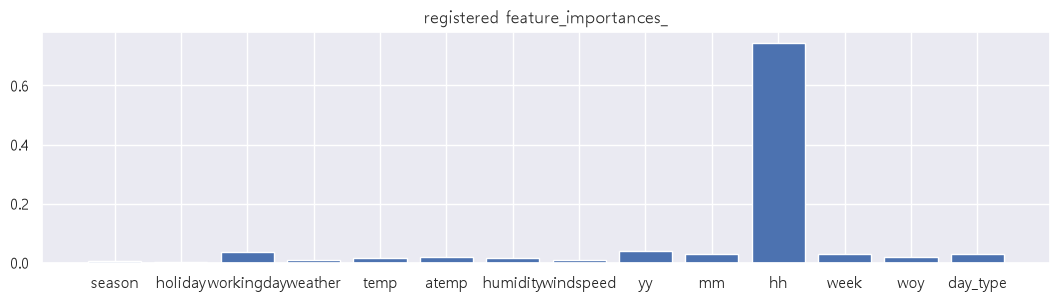

In [65]:
imp = model_r.feature_importances_
#print(imp)
#print(train[col_list].columns)

plt.figure(figsize=(13,3))

plt.bar(train[col_list].columns, imp)
plt.title("registered feature_importances_")
plt.tight_layout
plt.show()

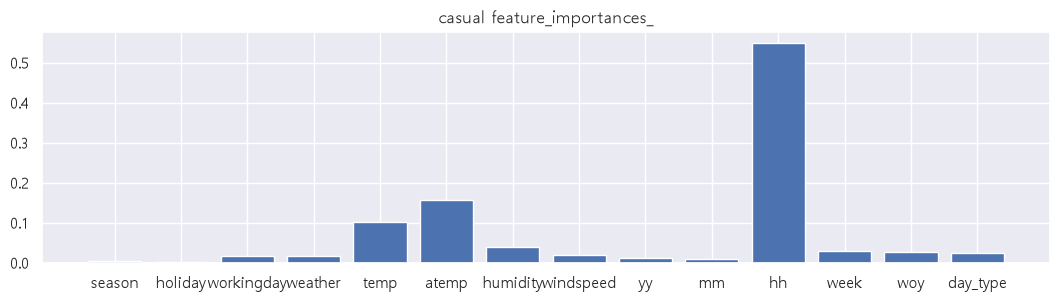

In [66]:
imp = model_c.feature_importances_
#print(imp)
#print(train[col_list].columns)

plt.figure(figsize=(13,3))

plt.bar(train[col_list].columns, imp)
plt.title("casual feature_importances_")
plt.tight_layout
plt.show()

## (2) 파생피쳐 생성
* peak, ideal, sticky

In [67]:
for i, df in enumerate ([train, test]) :
    df['peak'] = df[['hh', 'workingday']].apply(
        lambda x: 1 if (
            (x['workingday'] == 1 and ( x['hh'] == 8 or 17 <= x['hh'] <= 18 or 12 <= x['hh'] <= 13))
            or
            (x['workingday'] == 0 and (10 <= x['hh'] <= 19) )
        ) else 0,
        axis=1
    )
    
    df['ideal'] = df[['temp', 'windspeed']].apply(
        lambda x: 1 if x['temp'] > 27 and x['windspeed'] < 30 else 0,
        axis=1
    )
    
    df['sticky'] = df[['humidity', 'workingday']].apply(
        lambda x: 1 if x['workingday'] == 1 and x['humidity'] >= 60 else 0,
        axis=1
    )

    if i == 0:
        train = df
    elif i == 1:
        test = df

In [68]:
test.head(1)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,yy,mm,dd,hh,week,woy,day_type,peak,ideal,sticky
datetime,,,,,,,,,,,,,,,,,,
2011-01-20,1,0,1,1,10.66,11.365,56,26.0027,2011,1,20,0,3,3,0,0,0,0


## (3) 습도(이상치) 삭제
* humidity < 2

In [69]:
print(train.shape)
train = train.drop(train[train['humidity'] <= 2].index)
print(train.shape)

(10886, 21)
(10864, 21)


# **[6] 강력한 모델로 교체**
* 선형 보다는 트리모델이 좋은 성능을 보임
* pip install xgboost, lightgbm
* <font color=red> <b> sklearn 기본모델 : GradientBoosting, RandomForest

## **GradientBoosting**
* Gradient Boosting : 여러 개의 단순하고 약한 예측 모델(주로 의사결정 트리)을 순차적으로 결합해 강력한 예측 성능을 만드는 앙상블(Ensemble) 학습 알고리즘

> 파라미터 튜닝 : 모델 성능을 위해 주요 하이퍼파라미터 기본값을 수정하는 것 (튜닝을 위한 별도 tool 활용 가능)

In [70]:
params = {
    'n_estimators': 150,
    'max_depth': 5,
    'random_state': 0,
    'min_samples_leaf': 10,
    'learning_rate': 0.1,
    'subsample': 0.7,
    'loss': 'squared_error'  #---ls
}

gb_r_model = GradientBoostingRegressor(**params)
gb_c_model = GradientBoostingRegressor(**params)

gbm_cols = ['weather', 'temp', 'humidity', 'windspeed', 'holiday', 'workingday', 'season', 'hh', 'week', 'yy', 'ideal']

In [71]:
gb_r, gb_c = myscore222(train, model_r=gb_r_model, model_c=gb_c_model, input_cols=gbm_cols)

GradientBoostingRegressor
GradientBoostingRegressor
rmsle : 0.3104


## **Random Forest**
* 여러 개의 결정 트리(Decision Tree)를 모아 숲을 형성하고, 이들의 예측 결과를 종합하여 더 정확한 최종 결론을 내리는 앙상블(Ensemble) 머신러닝 알고리즘

In [72]:
params = {'n_estimators': 1000, 'max_depth': 15, 'random_state': 0, 'min_samples_split' : 5, 'n_jobs': -1}

rf_r_model = RandomForestRegressor(**params)
rf_c_model = RandomForestRegressor(**params)

rf_cols = ['weather', 'temp', 'windspeed', 'workingday', 'season', 'holiday', 'sticky', 'hh', 'week', 'woy', 'peak']

In [73]:
rf_r, rf_c = myscore222(train, model_r=rf_r_model, model_c=rf_c_model, input_cols=rf_cols)

RandomForestRegressor
RandomForestRegressor
rmsle : 0.4340


## <font color=blue> **→3차 점수 : 모델교체**
* 1차 : 0.3173
* 2차 : 0.3153
* 3차 : gb-0.3213 / rf-0.4380

# **[7] 공모전 test 예측**
* 각각 예측해서 합산

In [74]:
gbm_pred = mypred(test[gbm_cols], model_r=gb_r, model_c=gb_c, MY_FNAME=None)

rf_pred = mypred(test[rf_cols], model_r=rf_r, model_c=rf_c, MY_FNAME=None)

final_pred = np.round(.20*rf_pred + .80*gbm_pred)

GradientBoostingRegressor
GradientBoostingRegressor
RandomForestRegressor
RandomForestRegressor


In [75]:
sub['count'] = final_pred
sub.to_csv("lec11_final.csv", index=False)

## <font color=blue> **→4차 점수 : 코드 수정 + 달력 추가**
* 1차 : 0.3173
* 2차 : 0.3153
* 3차 : gb-0.3213 / rf-0.4380
* <b> 4차(최종) : 0.36194 -- 15등(Global top 0.4%)

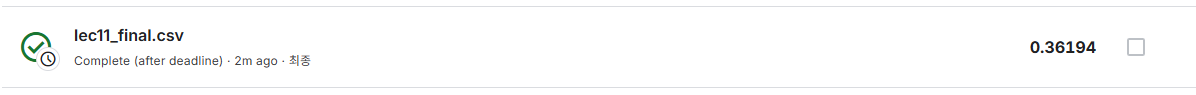